# Learnings
- Softmax is `e^x/sum(e^x)`
- Log Softmax is `log(e^x/sum(e^x))` = `log(e^x) - log(sum(e^x))` = `x - log(sum(e^x))`
- Log Softmax is used because
  - NLLoss/CELoss work with log probs
  - It is numerically more stable
- CE Loss = LogSoftmax + NLL
  - LogSoftmax is above
  - NLL = You just collect all the losses at the GT index and calculate their mean and then -ve it. so NLL = -1 * sum(log_softmax @ the GT index)
- In Pytorch, `tensor[[0,1], [0,1]]` will get `tensor[0][0]` and `tensor[1][1]`
  - `preds[2:5, :2]` this shit is same as in numpy

In [ ]:
# https://docs.pytorch.org/tutorials/beginner/nn_tutorial.html

In [ ]:
import torch

In [3]:
from pathlib import Path
import requests

DATA_PATH = Path("data")
PATH = DATA_PATH / "mnist"

PATH.mkdir(parents=True, exist_ok=True)

URL = "https://github.com/pytorch/tutorials/raw/main/_static/"
FILENAME = "mnist.pkl.gz"

if not (PATH / FILENAME).exists():
        content = requests.get(URL + FILENAME).content
        (PATH / FILENAME).open("wb").write(content)

In [4]:
import pickle
import gzip

with gzip.open((PATH / FILENAME).as_posix(), "rb") as f:
  ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")

(50000, 784)


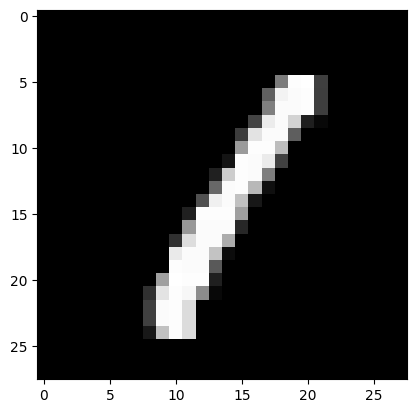

In [5]:
from matplotlib import pyplot
import numpy as np

pyplot.imshow(x_train[3].reshape((28, 28)), cmap="gray")
# ``pyplot.show()`` only if not on Colab
try:
    import google.colab
except ImportError:
    pyplot.show()
print(x_train.shape)

In [6]:
x_train, y_train, x_valid, y_valid = map(
    torch.tensor, (x_train, y_train, x_valid, y_valid)
)
n, c = x_train.shape

In [7]:
x_train.shape

torch.Size([50000, 784])

# Neural Net without torch.nn

In [8]:
import math
import torch

In [9]:
weights = torch.randn(784, 10) / math.sqrt(78)
weights.requires_grad_()
bias = torch.zeros(10, requires_grad=True)

In [10]:
def log_softmax(x):
  return x - x.exp().sum(1).log().unsqueeze(-1)

In [11]:
def model(xb):
  logits = xb @ weights + bias
  log_probs = log_softmax(logits)
  return log_probs

In [12]:
def nll(preds, gt):
  return -preds[range(preds.shape[0]), gt].mean()
loss_fn = nll

In [13]:
def accuracy(preds, gt):
  return (torch.argmax(preds, dim=1) == yb).float().mean()

In [14]:
import math

weights = torch.randn(784, 10, requires_grad=True) / math.sqrt(78)
bias = torch.zeros(10, requires_grad=True)

def log_softmax(x):
  return x - x.exp().sum(1).log().unsqueeze(-1)

def model(xb):
  logits = xb @ weights + bias
  log_probs = log_softmax(logits)
  return log_probs

def nll(preds, gt):
  return -preds[range(preds.shape[0]), gt].mean()
loss_fn = nll

def accuracy(preds, gt):
  return (torch.argmax(preds, dim=1) == yb).float().mean()

epochs, bs, lr = 2, 64, 1e-6
for epoch in range(epochs):
  for i in range(0, x_train.shape[0], bs):
    start_idx = i
    end_idx = start_idx + bs

    # Dataloader batch size
    xb = x_train[start_idx:end_idx]
    yb = y_train[start_idx:end_idx]


    # Forward pass
    preds = model(xb)

    # Calculate loss
    loss = loss_fn(preds, yb)

    # Calculate the gradients
    loss.backward()

    # Optimizer step
    with torch.no_grad():
      weights -= lr * weights.grad
      bias -= lr * bias.grad
      ## Zero grad the weights and biases
      weights.grad.zero_()
      bias.grad.zero_()

/tmp/ipython-input-1283802123.py:43: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:492.)
  weights -= lr * weights.grad


TypeError: unsupported operand type(s) for *: 'float' and 'NoneType'

In [18]:
## Revision

In [19]:
yb

tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9, 4, 0, 9, 1,
        1, 2, 4, 3, 2, 7, 3, 8, 6, 9, 0, 5, 6, 0, 7, 6, 1, 8, 7, 9, 3, 9, 8, 5,
        9, 3, 3, 0, 7, 4, 9, 8, 0, 9, 4, 1, 4, 4, 6, 0])

In [22]:
logits = xb @ weights + bias

In [25]:
log_probs = log_softmax(logits)
log_probs.shape

torch.Size([64, 10])

In [27]:
logits.shape

torch.Size([64, 10])

In [28]:
preds.shape, yb.shape

(torch.Size([64, 10]), torch.Size([64]))

In [ ]:
-preds[range(preds.shape[0]), gt].mean()

In [48]:
preds[[0,1,2], yb[[0,1,2]]]

tensor([-3.5218, -2.3128, -2.9944], grad_fn=<IndexBackward0>)

In [43]:
preds

tensor([[-1.7791, -2.7880, -2.6477, -1.9808, -1.0361, -3.5218, -2.8155, -4.3590,
         -3.8065, -2.5057],
        [-2.3128, -2.3692, -1.1734, -3.8992, -1.3353, -2.6157, -2.7980, -3.5120,
         -4.4005, -3.2534],
        [-2.3334, -1.9017, -2.1228, -1.5129, -2.9944, -2.8887, -3.4146, -2.8532,
         -3.3535, -1.7008],
        [-1.8983, -2.3413, -2.2623, -1.8542, -3.0359, -2.1983, -3.2727, -4.1903,
         -1.9544, -1.9692],
        [-1.4413, -1.7143, -2.7291, -4.7118, -1.9970, -2.8562, -2.0985, -3.9066,
         -4.8793, -1.7991],
        [-2.5537, -1.0827, -2.1388, -4.0230, -2.1955, -3.0882, -2.2913, -4.8732,
         -3.6814, -1.8517],
        [-1.2715, -2.4468, -2.5012, -3.4007, -2.1835, -2.2085, -3.2222, -2.7418,
         -2.2800, -2.4242],
        [-1.6391, -2.5634, -1.9629, -1.1867, -2.6904, -3.3612, -3.4515, -5.7673,
         -3.4302, -2.1771],
        [-1.7813, -2.1470, -2.0927, -2.9205, -2.1478, -2.5132, -2.4174, -2.0905,
         -3.0932, -2.5060],
        [-2.1170, -

## Refactor using nn.Module

In [ ]:
class MyModel(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = torch.nn.Parameter(torch.randn(784, 10) / math.sqrt(784))
    self.bias = torch.nn.Parameter(torch.zeros(10))

  def forward(self, x):
    return x @ self.weights + bias

model = MyModel()

In [ ]:
import torch.nn.functional as F
loss_fn = F.cross_entropy

In [ ]:
loss_fn(model(xb), yb)

tensor(2.4067, grad_fn=<NllLossBackward0>)

## Refactor using nn.Linear

In [ ]:
class MyModel(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = torch.nn.Linear(784, 10, bias=True)

  def forward(self, x):
    return self.linear_layer(x)

model = MyModel()

In [ ]:
model(xb).shape

torch.Size([64, 10])

## Refactor using Dataset

In [ ]:
from torch.utils.data import TensorDataset

In [ ]:
train_ds = TensorDataset(x_train, y_train)

## Refactor using Dataloader

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
train_dl = DataLoader(train_ds, batch_size=64)

In [ ]:
for xb, yb in train_dl:
  preds = model(xb)
  loss = loss_fn(preds, yb)

In [ ]:
loss

tensor(2.2617, grad_fn=<NllLossBackward0>)

## Use validation after every epoch

In [ ]:
train_ds = TensorDataset(x_train, y_train)
val_ds = TensorDataset(x_valid, y_valid)

In [ ]:
train_dl = DataLoader(train_ds, batch_size=64)
val_dl = DataLoader(val_ds, batch_size=64)

In [ ]:
from torch.optim import SGD
optimizer = SGD(model.parameters(), lr=1e-3)

In [ ]:
epochs = 10
for i in range(epochs):
  model.train()
  for xb, yb in train_dl:
    preds = model(xb)
    loss = loss_fn(preds, yb)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  model.eval()
  with torch.no_grad():
    running_loss = 0
    for xb, yb in val_dl:
      preds = model(xb)
      loss = loss_fn(preds, yb).item()
      running_loss += loss
  print(i, float(running_loss) / len(val_dl))

0 0.4288542420621131
1 0.42523430340039503
2 0.42180180274377205
3 0.41854158499438293
4 0.41544016934694
5 0.4124854414895841
6 0.4096665617766654
7 0.40697368125247346
8 0.4043979761516972
9 0.4019314072978724


In [ ]:
# Next: https://docs.pytorch.org/tutorials/beginner/understanding_leaf_vs_nonleaf_tutorial.html